In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Dropout
from sklearn.preprocessing import StandardScaler
from keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import time

In [3]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [4]:
X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

In [5]:
y_train_one_hot = to_categorical(y_train,num_classes=10)

y_test_one_hot = to_categorical(y_test,num_classes=10)

In [6]:
test_accuracy_list = []

https://docs.pytorch.org/docs/2.13/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html

In [225]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
X_train_scaled = X_train.reshape(X_train.shape[0], -1) / 255.0
X_test_scaled = X_test.reshape(X_test.shape[0], -1) / 255.0


time_start = time.time()

model = Sequential()
model.add(Dense(units=256,activation='relu', input_dim=X_train_scaled.shape[1]))
model.add(Dropout(0.15))
model.add(Dense(units=256, activation='relu'))
# model.add(Dropout(0.15))
model.add(Dense(units=10,activation='softmax'))

# Compile model
### 'categorical_crossentropy'tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)
model.compile(optimizer='nadam',loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), metrics=['accuracy'])

# Add the checkpoint for best model
early_stopping = EarlyStopping(patience=5,restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.h5',monitor='val_accuracy',mode='max',save_best_only=True,verbose=1)
# train the model

history = model.fit(X_train_scaled,y_train_one_hot,epochs=30,batch_size=64,validation_split=0.2,callbacks=[checkpoint,early_stopping,reduce_lr],verbose=1)

test_loss,test_accuracy=model.evaluate(X_test_scaled,y_test_one_hot)
print('Test accuracy: ', test_accuracy)
time_end = time.time()
test_accuracy_list.append(test_accuracy)
print(f'This took {time_end - time_start} seconds to run')

Epoch 1/30
745/750 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7701 - loss: 1.0465
Epoch 1: val_accuracy improved from None to 0.86233, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.8248 - loss: 0.9233 - val_accuracy: 0.8623 - val_loss: 0.8210 - learning_rate: 0.0010
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8660 - loss: 0.8191
Epoch 2: val_accuracy improved from 0.86233 to 0.87300, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8675 - loss: 0.8136 - val_accuracy: 0.8730 - val_loss: 0.7865 - learning_rate: 0.0010
Epoch 3/30
746/750 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8774 - loss: 0.7862
Epoch 3: val_accuracy improved from 0.87300 to 0.87967, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8793 - loss: 0.7813 - val_accuracy: 0.8797 - val_loss: 0.7715 - learning_rate: 0.0010
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8900 - loss: 0.7559
Epoch 4: val_accuracy improved from 0.87967 to 0.88317, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8862 - loss: 0.7591 - val_accuracy: 0.8832 - val_loss: 0.7661 - learning_rate: 0.0010
Epoch 5/30
748/750 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8905 - loss: 0.7473
Epoch 5: val_accuracy did not improve from 0.88317
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8916 - loss: 0.7445 - val_accuracy: 0.8827 - val_loss: 0.7577 - learning_rate: 0.0010
Epoch 6/30
747/750 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8985 - loss: 0.7295
Epoch 6: val_accuracy improved from 0.88317 to 0.88542, saving model to best_model.h5


...


Epoch 20: finished saving model to best_model.h5
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9470 - loss: 0.6223 - val_accuracy: 0.9052 - val_loss: 0.7144 - learning_rate: 2.5000e-04
Epoch 21/30
748/750 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9478 - loss: 0.6197
Epoch 21: val_accuracy improved from 0.90517 to 0.90567, saving model to best_model.h5



Epoch 21: finished saving model to best_model.h5
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9483 - loss: 0.6187 - val_accuracy: 0.9057 - val_loss: 0.7128 - learning_rate: 2.5000e-04
Epoch 22/30
747/750 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9516 - loss: 0.6154
Epoch 22: val_accuracy did not improve from 0.90567
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9503 - loss: 0.6163 - val_accuracy: 0.9030 - val_loss: 0.7166 - learning_rate: 2.5000e-04
Epoch 23/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9507 - loss: 0.6140
Epoch 23: val_accuracy improved from 0.90567 to 0.90583, saving model to best_model.h5



Epoch 23: finished saving model to best_model.h5
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9504 - loss: 0.6153 - val_accuracy: 0.9058 - val_loss: 0.7145 - learning_rate: 2.5000e-04
Epoch 24/30
744/750 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9548 - loss: 0.6046
Epoch 24: val_accuracy did not improve from 0.90583
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9549 - loss: 0.6058 - val_accuracy: 0.9055 - val_loss: 0.7126 - learning_rate: 1.2500e-04
Epoch 25/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9563 - loss: 0.6042
Epoch 25: val_accuracy improved from 0.90583 to 0.90608, saving model to best_model.h5



Epoch 25: finished saving model to best_model.h5
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9560 - loss: 0.6036 - val_accuracy: 0.9061 - val_loss: 0.7120 - learning_rate: 1.2500e-04
Epoch 26/30
748/750 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9572 - loss: 0.6026
Epoch 26: val_accuracy improved from 0.90608 to 0.90750, saving model to best_model.h5



Epoch 26: finished saving model to best_model.h5
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9571 - loss: 0.6026 - val_accuracy: 0.9075 - val_loss: 0.7123 - learning_rate: 1.2500e-04
Epoch 27/30
746/750 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9586 - loss: 0.6002
Epoch 27: val_accuracy did not improve from 0.90750
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9581 - loss: 0.6009 - val_accuracy: 0.9055 - val_loss: 0.7139 - learning_rate: 1.2500e-04
Epoch 28/30
748/750 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9591 - loss: 0.5979
Epoch 28: val_accuracy did not improve from 0.90750
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9595 - loss: 0.5973 - val_accuracy: 0.9057 - val_loss: 0.7130 - learning_rate: 6.2500e-05
Epoch 29/30
747/750 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9600 - loss: 0.5948
Epoch 29: val_accuracy did not improve from 0.90750
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9600 - loss: 0.5966 - val_accuracy: 0.90

In [226]:
best_model = tf.keras.models.load_model('best_model.h5')


In [227]:
best_model.summary()

Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_117 (Dense)               │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_61 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_118 (Dense)               │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_119 (Dense)               │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,325 (1.03 MB)

 Trainable params: 269,322 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3 (16.00 B)

In [228]:
test_accuracy_list

[0.8878999948501587,
 0.8798999786376953,
 0.8781999945640564,
 0.8950999975204468,
 0.8978000283241272,
 0.8919000029563904,
 0.8931999802589417,
 0.888700008392334,
 0.8955000042915344,
 0.8973000049591064,
 0.8917999863624573,
 0.8985000252723694,
 0.8930000066757202,
 0.8896999955177307,
 0.8982999920845032,
 0.8939999938011169,
 0.8924999833106995,
 0.8942999839782715,
 0.8968999981880188,
 0.8953999876976013,
 0.8888999819755554,
 0.8898000121116638,
 0.8989999890327454,
 0.8924999833106995,
 0.8980000019073486,
 0.890999972820282,
 0.8985999822616577,
 0.8892999887466431,
 0.8981000185012817,
 0.9009000062942505,
 0.8973000049591064,
 0.9000999927520752,
 0.8984000086784363,
 0.897599995136261,
 0.8966000080108643,
 0.8932999968528748,
 0.8964999914169312,
 0.9010999798774719]

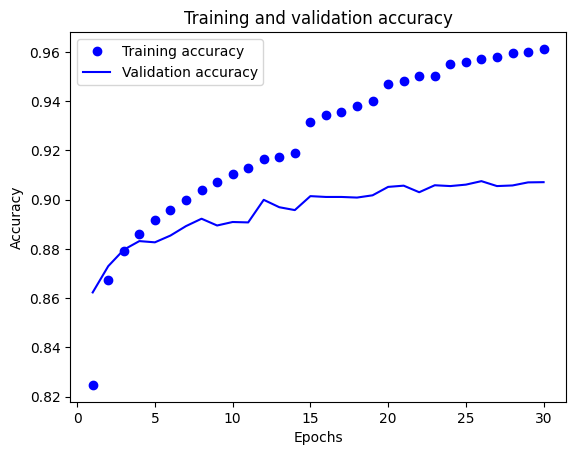

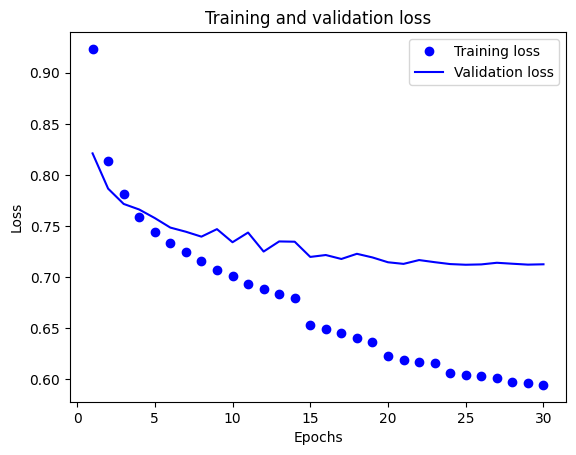

In [229]:
accuracy_values = history.history['accuracy']
val_accuracy_values = history.history['val_accuracy']

loss_values = history.history['loss']
val_loss_values = history.history['val_loss']

epochs = range(1,len(accuracy_values) + 1)

plt.plot(epochs, accuracy_values, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy_values, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [230]:
result = model.predict(X_test_scaled)
predicted_classes = np.argmax(result, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [231]:
predicted_classes

array([9, 2, 1, ..., 8, 1, 5])

In [232]:
y_test

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)

In [233]:
from sklearn.metrics import classification_report,accuracy_score
print(classification_report(predicted_classes,y_test))
print(accuracy_score(predicted_classes,y_test))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1001
           1       0.98      0.99      0.99       988
           2       0.82      0.83      0.83       986
           3       0.91      0.89      0.90      1023
           4       0.83      0.81      0.82      1026
           5       0.97      0.98      0.97       990
           6       0.73      0.75      0.74       973
           7       0.97      0.96      0.96      1009
           8       0.98      0.98      0.98       999
           9       0.97      0.97      0.97      1005

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000

0.9011


**Висновок**

Точність модель досягла свого максимуму на рівні 0,9011 (90,11%). Найвищі показники точності (precision) зафіксовано для класів 1 та 8, тоді як найнижчий рівень точності має клас 6 — 0,73 (73%). Крім того, значення повноти (recall) є стабільними та не мають різкого розходження з відповідними показниками точності.